# Phase 2 — Model 2: Deep Autoencoder with Skip Connections

**Course:** AML-DL Project | **Authors:** Prerak Arya (230039), Saikiran Bompelliwar (230046)

This notebook implements a deep autoencoder with skip connections, weighted MSE loss, and curriculum learning for semi-supervised anomaly detection.

## Model Summary

| Property | Value |
|----------|-------|
| **Type** | Deep Autoencoder with residual connections |
| **Architecture** | 43 → 128 → 64 → 32 (bottleneck) → 64 → 128 → 43 |
| **Skip connections** | enc1↔dec3, enc2↔dec2 |
| **Loss function** | Weighted MSE (inverse-variance feature weighting) |
| **Training** | Curriculum learning (3 stages: easy → medium → hard) |
| **Regularisation** | BatchNorm, Dropout(0.2), Weight Decay(1e-5), Early Stopping |
| **Optimiser** | Adam (lr=1e-3) with ReduceLROnPlateau |
| **Cross-domain innovation** | Skip connections adapted from ResNet (He et al., 2016) to tabular anomaly detection |
| **Paper adaptation note** | Follows "Autoencoder-Based Anomaly Detection in Network Traffic" reconstruction workflow, with NSL-KDD-specific modifications (skip links, weighted loss, curriculum) |

### Architecture Diagram

```
Input (43) ──→ [Linear→BN→LReLU→Drop] ──→ [Linear→BN→LReLU→Drop] ──→ [Linear→BN→LReLU]
               128 (h1)                     64 (h2)                     32 (bottleneck z)
                │                            │                            │
                │         skip connections    │                            │
                │                            │                            ↓
Output (43) ←── [Linear] ←─── concat ←── [Linear→BN→LReLU→Drop] ←── [Linear→BN→LReLU→Drop]
                256→43         128+128=256   128→128                    64→64 ← concat(64+h2)
                               ↑                                              ↑
                               h1                                             h2
```

---

In [8]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from utils.config import SEED, DEVICE, RESULTS_DIR, MODELS_DIR
from utils.models import AutoencoderSkip, WeightedMSELoss
from utils.evaluation import compute_recon_error, find_threshold, eval_model, plot_cm, plot_scores
from utils.data_loader import setup_curriculum

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device: {DEVICE}")

Device: mps


## 1. Load Preprocessed Data

---

In [9]:
data = np.load(os.path.join(RESULTS_DIR, 'processed_data.npz'), allow_pickle=True)
X_train_scaled = data['X_train_scaled']
X_val_normal_scaled = data['X_val_normal_scaled']
X_val_mixed_scaled = data['X_val_mixed_scaled']
X_test_scaled = data['X_test_scaled']
y_val_mixed = data['y_val_mixed']
y_test = data['y_test']
test_attack_cats = data['test_attack_cats']

input_dim = X_train_scaled.shape[1]
print(f"Train: {X_train_scaled.shape}, Input dim: {input_dim}")

Train: (53874, 43), Input dim: 43


## 2. Model Architecture

We instantiate the AutoencoderSkip model and examine its parameter count. The model is lightweight (~50K parameters) to run efficiently on 8GB RAM.

---

In [10]:
ae_model = AutoencoderSkip(dim=input_dim).to(DEVICE)
n_params = sum(p.numel() for p in ae_model.parameters())
n_trainable = sum(p.numel() for p in ae_model.parameters() if p.requires_grad)

print(f"AutoencoderSkip Architecture")
print("=" * 60)
print(ae_model)
print(f"\nTotal parameters: {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")
print(f"Model size: {n_params * 4 / 1024:.1f} KB (float32)")

# Layer-by-layer breakdown
print(f"\nLayer-by-Layer Parameter Count:")
print("-" * 40)
for name, param in ae_model.named_parameters():
    print(f"  {name:<30} {str(list(param.shape)):>15} = {param.numel():>6,}")

AutoencoderSkip Architecture
AutoencoderSkip(
  (enc1): Sequential(
    (0): Linear(in_features=43, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.2, inplace=False)
  )
  (enc2): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.2, inplace=False)
  )
  (enc3): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (dec1): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.

## 3. Weighted MSE Loss Setup

We compute inverse-variance weights from the training data. Features with low variance in normal traffic receive higher weight — deviations in these features are more informative for anomaly detection.

---

In [11]:
feat_vars = X_train_scaled.var(axis=0)
feat_w = 1.0 / (feat_vars + 1e-6)
feat_w = feat_w / feat_w.mean()
feat_w_t = torch.FloatTensor(feat_w).to(DEVICE)

print("Feature Weights (inverse-variance, normalised):")
print("=" * 60)
print(f"{'Feature Index':<15} {'Variance':>10} {'Weight':>10}")
print("-" * 60)
sorted_idx = np.argsort(feat_w)[::-1]
for i in sorted_idx[:10]:
    print(f"  Feature {i:<6} {feat_vars[i]:>10.4f} {feat_w[i]:>10.4f}")
print(f"  ...")
for i in sorted_idx[-5:]:
    print(f"  Feature {i:<6} {feat_vars[i]:>10.4f} {feat_w[i]:>10.4f}")
print(f"\nWeight range: [{feat_w.min():.4f}, {feat_w.max():.4f}]")
print(f"Max/min ratio: {feat_w.max()/feat_w.min():.1f}x")

criterion_ae = WeightedMSELoss(weights=feat_w_t)
print("\nWeightedMSELoss initialised.")

Feature Weights (inverse-variance, normalised):
Feature Index     Variance     Weight
------------------------------------------------------------
  Feature 7          0.0000    42.9982
  Feature 13         1.0000     0.0000
  Feature 0          1.0000     0.0000
  Feature 24         1.0000     0.0000
  Feature 17         1.0000     0.0000
  Feature 37         1.0000     0.0000
  Feature 31         1.0000     0.0000
  Feature 28         1.0000     0.0000
  Feature 34         1.0000     0.0000
  Feature 11         1.0000     0.0000
  ...
  Feature 19         1.0000     0.0000
  Feature 42         1.0000     0.0000
  Feature 18         1.0000     0.0000
  Feature 36         1.0000     0.0000
  Feature 38         1.0000     0.0000

Weight range: [0.0000, 42.9982]
Max/min ratio: 1000001.0x

WeightedMSELoss initialised.


## 4. Curriculum Learning Setup

---

In [12]:
curriculum_stages, epochs_per_stage, distances = setup_curriculum(X_train_scaled)

print("Curriculum Learning Configuration:")
for (name, idx), epochs in zip(curriculum_stages, epochs_per_stage):
    print(f"  {name}: {len(idx):,} samples, {epochs} epochs")
print(f"  Total epochs: {sum(epochs_per_stage)}")

Curriculum Learning Configuration:
  Easy — closest 33%: 17,958 samples, 15 epochs
  Medium — closest 66%: 35,916 samples, 15 epochs
  All — 100%: 53,874 samples, 20 epochs
  Total epochs: 50


## 5. Training Loop

We train the autoencoder using curriculum learning across 3 stages, with early stopping and learning rate scheduling.

---

In [13]:
optimizer_ae = optim.Adam(ae_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_ae = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ae, mode='min', patience=5, factor=0.5)

X_val_t = torch.FloatTensor(X_val_normal_scaled).to(DEVICE)
ae_train_losses, ae_val_losses = [], []
best_val_loss, patience_ctr, PATIENCE = float('inf'), 0, 10
total_epoch = 0
stage_boundaries = []

print("=" * 60)
print("TRAINING: Autoencoder with Skip Connections")
print("=" * 60)
t_start = time.time()

for stage_i, ((sname, sidx), sepochs) in enumerate(
        zip(curriculum_stages, epochs_per_stage)):
    print(f"\n{'─'*60}")
    print(f"Stage {stage_i+1}: {sname} ({sepochs} epochs, {len(sidx):,} samples)")
    print(f"{'─'*60}")

    X_stage = torch.FloatTensor(X_train_scaled[sidx])
    loader = DataLoader(TensorDataset(X_stage), batch_size=128,
                        shuffle=True, drop_last=False)
    stage_boundaries.append(total_epoch)

    for ep in range(sepochs):
        total_epoch += 1
        ae_model.train()
        ep_loss = 0
        for batch in loader:
            x = batch[0].to(DEVICE)
            recon, _ = ae_model(x)
            loss = criterion_ae(recon, x)
            optimizer_ae.zero_grad()
            loss.backward()
            optimizer_ae.step()
            ep_loss += loss.item() * len(x)

        tl = ep_loss / len(X_stage)
        ae_train_losses.append(tl)

        ae_model.eval()
        with torch.no_grad():
            vr, _ = ae_model(X_val_t)
            vl = nn.functional.mse_loss(vr, X_val_t).item()
        ae_val_losses.append(vl)
        scheduler_ae.step(vl)

        if vl < best_val_loss:
            best_val_loss = vl
            patience_ctr = 0
            torch.save(ae_model.state_dict(), os.path.join(MODELS_DIR, 'best_ae.pth'))
        else:
            patience_ctr += 1

        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {total_epoch}")
            break
        if total_epoch % 5 == 0:
            lr = optimizer_ae.param_groups[0]['lr']
            print(f"  Epoch {total_epoch:>3d}: Train={tl:.6f} Val={vl:.6f} LR={lr:.2e}")

    if patience_ctr >= PATIENCE:
        break

total_time = time.time() - t_start
ae_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'best_ae.pth'), map_location=DEVICE))
print(f"\nTraining complete in {total_time:.1f}s")
print(f"Best val loss: {best_val_loss:.6f} at epoch {total_epoch - patience_ctr}")

TRAINING: Autoencoder with Skip Connections

────────────────────────────────────────────────────────────
Stage 1: Easy — closest 33% (15 epochs, 17,958 samples)
────────────────────────────────────────────────────────────
  Epoch   5: Train=0.000577 Val=2.303311 LR=1.00e-03
  Epoch  10: Train=0.000095 Val=2.201657 LR=1.00e-03
  Epoch  15: Train=0.000013 Val=2.180457 LR=1.00e-03

────────────────────────────────────────────────────────────
Stage 2: Medium — closest 66% (15 epochs, 35,916 samples)
────────────────────────────────────────────────────────────
  Epoch  20: Train=0.000002 Val=1.595543 LR=1.00e-03
  Epoch  25: Train=0.000002 Val=1.595212 LR=1.00e-03
  Epoch  30: Train=0.000003 Val=1.606018 LR=5.00e-04

────────────────────────────────────────────────────────────
Stage 3: All — 100% (20 epochs, 53,874 samples)
────────────────────────────────────────────────────────────
  Epoch  35: Train=0.000033 Val=1.454496 LR=5.00e-04
  Epoch  40: Train=0.000038 Val=1.586161 LR=2.50e-04
 

## 6. Training Curves

---

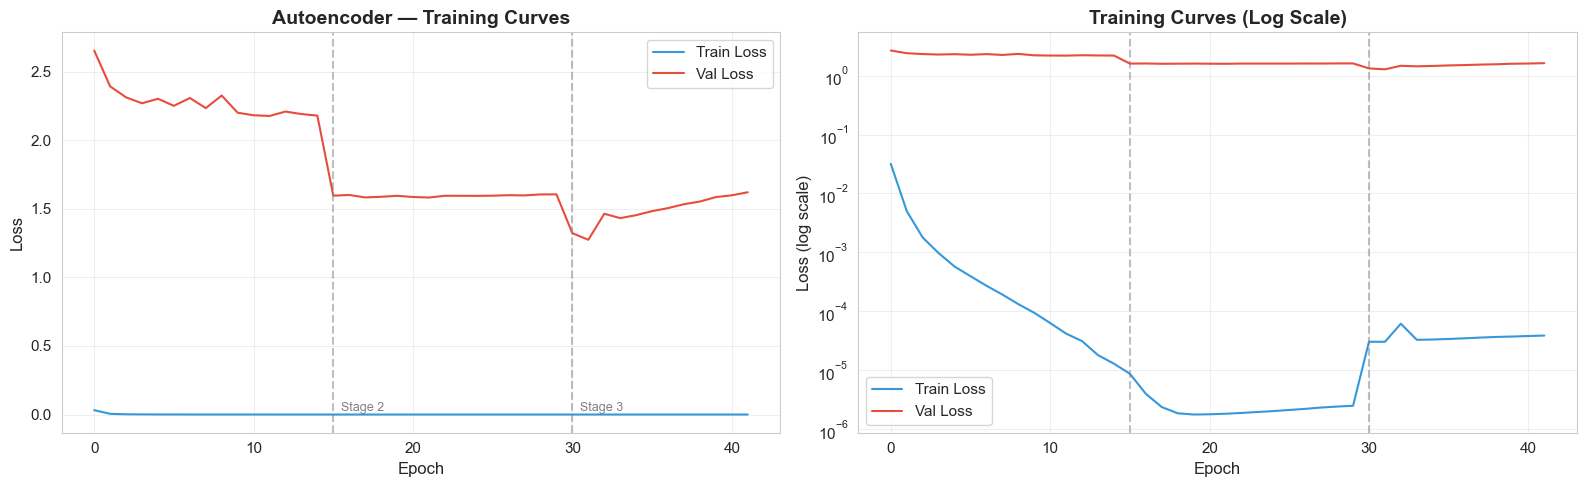

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss curves
axes[0].plot(ae_train_losses, label='Train Loss', color='#3498db', linewidth=1.5)
axes[0].plot(ae_val_losses, label='Val Loss', color='#e74c3c', linewidth=1.5)
for i, sb in enumerate(stage_boundaries[1:]):
    if sb < len(ae_train_losses):
        axes[0].axvline(sb, color='gray', linestyle='--', alpha=0.5)
        axes[0].text(sb + 0.5, max(ae_train_losses) * 0.9,
                     f'Stage {i+2}', fontsize=9, color='gray')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Autoencoder — Training Curves', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].semilogy(ae_train_losses, label='Train Loss', color='#3498db', linewidth=1.5)
axes[1].semilogy(ae_val_losses, label='Val Loss', color='#e74c3c', linewidth=1.5)
for i, sb in enumerate(stage_boundaries[1:]):
    if sb < len(ae_train_losses):
        axes[1].axvline(sb, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('Training Curves (Log Scale)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'ae_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Threshold Selection & Test Evaluation

We find the optimal anomaly score threshold on the **validation set** (mixed normal + attack samples) by maximising F1 score.

---

In [15]:
print("=" * 60)
print("EVALUATION: Autoencoder with Skip Connections")
print("=" * 60)

ae_val_scores = compute_recon_error(ae_model, X_val_mixed_scaled, DEVICE)
ae_threshold, ae_val_f1 = find_threshold(ae_val_scores, y_val_mixed)
print(f"Optimal threshold (val): {ae_threshold:.6f}")
print(f"Validation F1: {ae_val_f1:.4f}")

ae_test_scores = compute_recon_error(ae_model, X_test_scaled, DEVICE)
ae_test_preds = (ae_test_scores > ae_threshold).astype(int)

ae_metrics = eval_model(y_test, ae_test_preds, ae_test_scores, 'Autoencoder (Skip)')

EVALUATION: Autoencoder with Skip Connections
Optimal threshold (val): 0.036295
Validation F1: 0.6712

Autoencoder (Skip) — TEST RESULTS
              precision    recall  f1-score   support

      Normal       1.00      0.03      0.06      9711
     Anomaly       0.58      1.00      0.73     12833

    accuracy                           0.58     22544
   macro avg       0.79      0.51      0.39     22544
weighted avg       0.76      0.58      0.44     22544

ROC-AUC: 0.9320


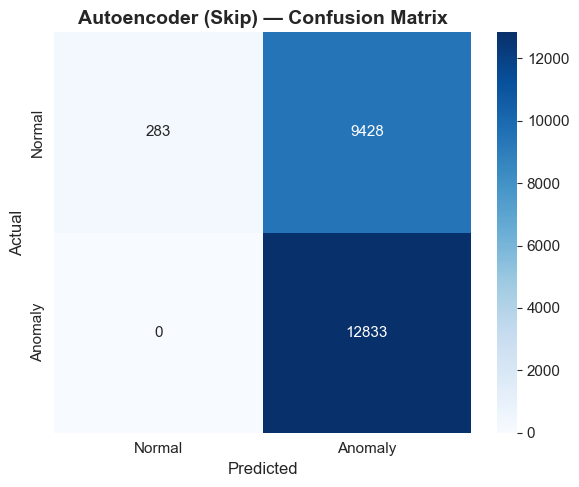

In [16]:
plot_cm(y_test, ae_test_preds, 'Autoencoder (Skip) — Confusion Matrix',
        os.path.join(RESULTS_DIR, 'ae_cm.png'))

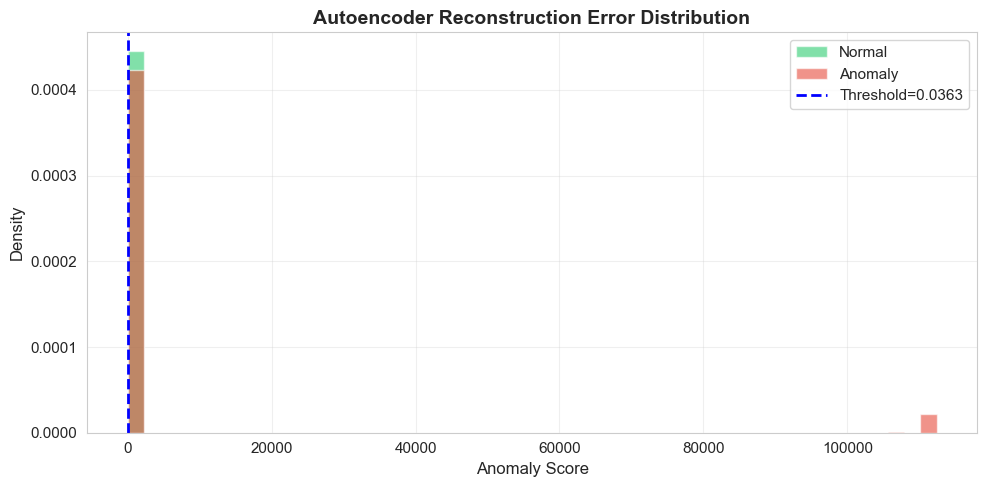

In [17]:
plot_scores(ae_test_scores, y_test, ae_threshold,
            'Autoencoder Reconstruction Error Distribution',
            os.path.join(RESULTS_DIR, 'ae_scores.png'))

## 8. Per-Attack-Family Analysis

---

In [18]:
print("Autoencoder: Per-Attack-Family Detection Rate")
print("=" * 55)
print(f"{'Family':<10} {'Total':>7} {'Detected':>10} {'Rate':>8}")
print("-" * 55)
for fam in ['DoS', 'Probe', 'R2L', 'U2R']:
    mask = test_attack_cats == fam
    total = mask.sum()
    if total == 0: continue
    detected = ae_test_preds[mask].sum()
    print(f"{fam:<10} {total:>7,d} {detected:>10,d} {detected/total:>7.1%}")

nm = test_attack_cats == 'Normal'
fp = ae_test_preds[nm].sum()
print("-" * 55)
print(f"{'Normal(FP)':<10} {nm.sum():>7,d} {fp:>10,d} {fp/nm.sum():>7.1%}")

Autoencoder: Per-Attack-Family Detection Rate
Family       Total   Detected     Rate
-------------------------------------------------------
DoS          7,458      7,458  100.0%
Probe        2,421      2,421  100.0%
R2L          2,887      2,887  100.0%
U2R             67         67  100.0%
-------------------------------------------------------
Normal(FP)   9,711      9,428   97.1%


## 9. Bottleneck Embeddings Visualisation

We visualise the 32-dimensional bottleneck representations in 2D using PCA. Good representations should show separation between normal and anomalous data.

---

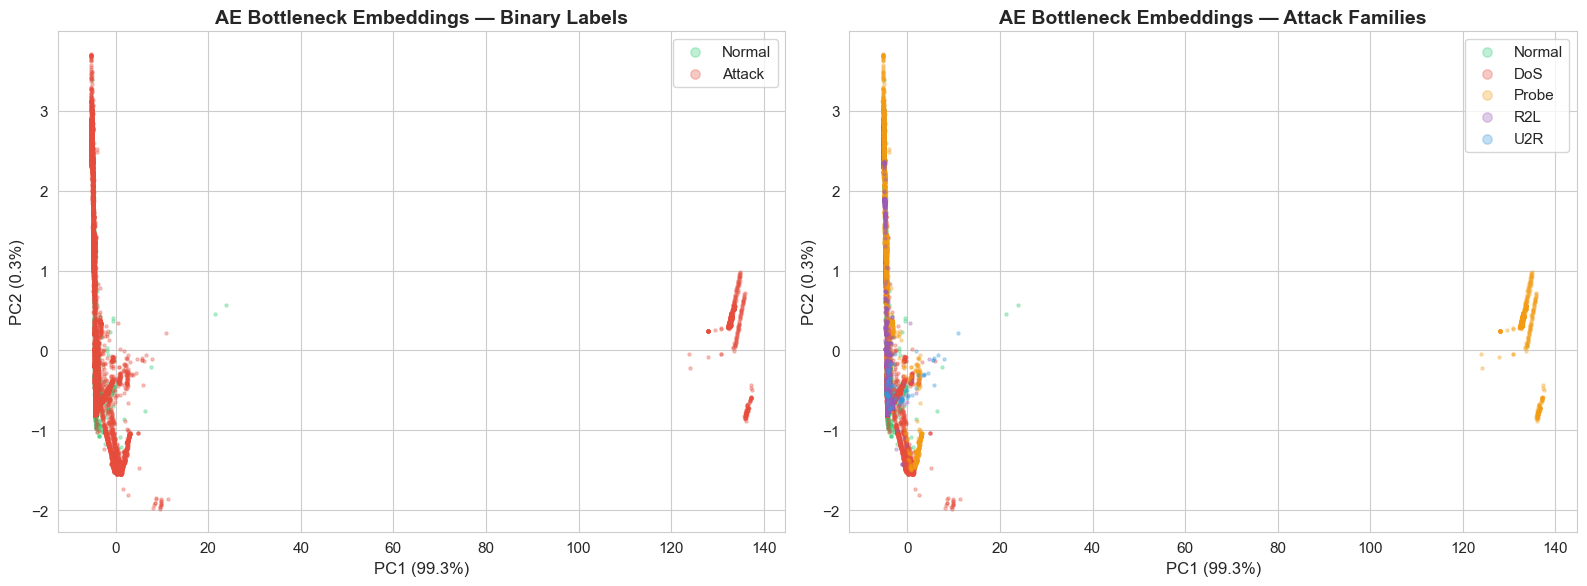

In [19]:
from sklearn.decomposition import PCA

ae_model.eval()
with torch.no_grad():
    test_t = torch.FloatTensor(X_test_scaled).to(DEVICE)
    ae_emb, _, _ = ae_model.encode(test_t)
    ae_emb_np = ae_emb.cpu().numpy()

pca_emb = PCA(n_components=2, random_state=SEED)
emb_2d = pca_emb.fit_transform(ae_emb_np)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By binary label
for label, color, name in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Attack')]:
    mask = y_test == label
    axes[0].scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=color,
                    s=5, alpha=0.3, label=name)
axes[0].set_title('AE Bottleneck Embeddings — Binary Labels', fontweight='bold')
axes[0].legend(markerscale=3)
axes[0].set_xlabel(f'PC1 ({pca_emb.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_emb.explained_variance_ratio_[1]:.1%})')

# By attack family
family_colors = {'Normal': '#2ecc71', 'DoS': '#e74c3c', 'Probe': '#f39c12',
                 'R2L': '#9b59b6', 'U2R': '#3498db'}
for fam, color in family_colors.items():
    mask = test_attack_cats == fam
    if mask.sum() > 0:
        axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=color,
                        s=5, alpha=0.3, label=fam)
axes[1].set_title('AE Bottleneck Embeddings — Attack Families', fontweight='bold')
axes[1].legend(markerscale=3)
axes[1].set_xlabel(f'PC1 ({pca_emb.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_emb.explained_variance_ratio_[1]:.1%})')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'ae_embeddings_2d.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Results

We save the model, scores, metrics, and bottleneck embeddings. The embeddings will be used in Phase 3 for the hybrid model.

---

In [20]:
np.save(os.path.join(MODELS_DIR, 'ae_test_embeddings.npy'), ae_emb_np)
np.save(os.path.join(MODELS_DIR, 'ae_test_scores.npy'), ae_test_scores)
np.save(os.path.join(MODELS_DIR, 'ae_test_preds.npy'), ae_test_preds)

metrics_df = pd.DataFrame([ae_metrics])
metrics_df.to_csv(os.path.join(RESULTS_DIR, 'ae_metrics.csv'), index=False)

print("Saved:")
print(f"  Model weights: {os.path.join(MODELS_DIR, 'best_ae.pth')}")
print(f"  Embeddings: {os.path.join(MODELS_DIR, 'ae_test_embeddings.npy')} shape={ae_emb_np.shape}")
print(f"  Scores: {os.path.join(MODELS_DIR, 'ae_test_scores.npy')}")
print(f"  Metrics: {os.path.join(RESULTS_DIR, 'ae_metrics.csv')}")
print(f"\nBottleneck embeddings saved for Phase 3 hybrid model.")

Saved:
  Model weights: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../models/best_ae.pth
  Embeddings: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../models/ae_test_embeddings.npy shape=(22544, 32)
  Scores: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../models/ae_test_scores.npy
  Metrics: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../results/ae_metrics.csv

Bottleneck embeddings saved for Phase 3 hybrid model.
